In [22]:
!pip install lime
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from lime.lime_tabular import LimeTabularExplainer

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='shap')
warnings.filterwarnings('ignore', category=FutureWarning, module='shap')
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd

df_fixed = pd.read_csv('rental_scam_model.csv', encoding='latin1')

print("\n📊 First 5 rows of the dataset:")
display(df_fixed.head())


📊 First 5 rows of the dataset:


,country,city,property_type,bedrooms,furnished,amenities_count,amenities_list,included_bills,included_bills_total,price,...,reputation_score,nationality_mismatch,min_stay_months,thumbs_up_count,thumbs_down_count,average_review_rating,rental_description,reviews,is_scam,label
0,France,Toulouse,flat,3,1,5,"Bike Storage, Concierge, Dishwasher, Gym, Wash...","Electricity, Gas/Heating, Laundry Room, WiFi",140,1248.0,...,58,False,3,44,1,4,Modern apartment in a sought-after development...,Communication with landlord was excellent. Ver...,0,Not Scam
1,Georgia,Tbilisi,house,2,0,6,"Balcony, Bike Storage, CCTV/Security, Dishwash...","Council Tax, Gas/Heating, Gym",195,539.0,...,57,False,6,19,8,4,Immaculate flat on a high floor with panoramic...,Property was exactly as described. Would recom...,0,Not Scam
2,Georgia,Batumi,flat,2,1,7,"Balcony, CCTV/Security, Concierge, Dishwasher,...","Council Tax, Electricity, TV Licence",193,494.0,...,17,True,3,5,21,3,"Urgent let! Owner moving abroad, needs reliabl...",Multiple people reporting this same listing on...,1,Scam
3,Germany,Berlin,studio,0,0,11,"Balcony, Bike Storage, Dishwasher, Garden, Gym...","Council Tax, Electricity, TV Licence, WiFi",218,1132.0,...,32,True,1,5,28,1,Best deal in the city Ã¢ÂÂ priced to go fast...,Deposit demanded before any contract or tenanc...,1,Scam
4,Germany,Munich,flat,2,1,7,"Bike Storage, Concierge, Dishwasher, Garden, L...","Council Tax, Gym",155,2238.0,...,41,True,3,11,17,1,Dream flat in city centre at student budget pr...,Agent said they would send keys by post. This ...,1,Scam


## Data for Training (7-Feature Deployment Schema)
This notebook trains and exports the deployed 7-feature scam model used by `main.py` and backend payloads.

In [24]:
print("Initializing 'df' with the fixed dataset...")

# Rename only fields used by the 7-feature pipeline
df_fixed = df_fixed.rename(columns={
    'thumbs_up_count': 'ThumbsUpCount',
    'thumbs_down_count': 'ThumbsDownCount',
    'included_bills_total': 'IncludedBillsTotal',
    'area_average_rent': 'AreaAveragePrice',
    'deposit_amount': 'DepositAmount',
    'price': 'Price',
    'reputation_score': 'ReputationScore',
    'nationality_mismatch': 'NationalityMismatch',
    'average_review_rating': 'AverageReviewRating',
    'rental_description': 'RentalDescription',
    'reviews': 'Reviews',
    'is_scam': 'IsScam'
})

df = df_fixed.copy()

# Data type corrections
df['ThumbsUpCount'] = pd.to_numeric(df['ThumbsUpCount'], errors='coerce').fillna(0).astype(int)
df['ThumbsDownCount'] = pd.to_numeric(df['ThumbsDownCount'], errors='coerce').fillna(0).astype(int)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').fillna(0.0)
df['DepositAmount'] = pd.to_numeric(df['DepositAmount'], errors='coerce').fillna(0.0)
df['AreaAveragePrice'] = pd.to_numeric(df['AreaAveragePrice'], errors='coerce').fillna(500.0)
df['ReputationScore'] = pd.to_numeric(df['ReputationScore'], errors='coerce').fillna(50.0).clip(0, 100)
df['NationalityMismatch'] = pd.to_numeric(df['NationalityMismatch'], errors='coerce').fillna(0).astype(int)
df['AverageReviewRating'] = pd.to_numeric(df['AverageReviewRating'], errors='coerce').fillna(3.0).clip(1, 5)
df['RentalDescription'] = df['RentalDescription'].fillna('')
df['Reviews'] = df['Reviews'].fillna('')

# Ensure binary label
df['IsScam'] = pd.to_numeric(df['IsScam'], errors='coerce')
df = df.dropna(subset=['IsScam']).copy()
df['IsScam'] = df['IsScam'].astype(int)
df = df[df['IsScam'].isin([0, 1])].copy()

print(f"✅ 'df' initialized with {len(df)} rows from the fixed dataset.")
print(f"   Scam: {df['IsScam'].sum()} ({df['IsScam'].sum()/len(df)*100:.1f}%)")
print(f"   Legit: {len(df) - df['IsScam'].sum()} ({(len(df) - df['IsScam'].sum())/len(df)*100:.1f}%)")
print("Displaying the first 5 rows of the updated 'df':")
display(df.head())

Initializing 'df' with the fixed dataset...
✅ 'df' initialized with 3382 rows from the fixed dataset.
   Scam: 1649 (48.8%)
   Legit: 1733 (51.2%)
Displaying the first 5 rows of the updated 'df':


,country,city,property_type,bedrooms,furnished,amenities_count,amenities_list,included_bills,IncludedBillsTotal,Price,...,ReputationScore,NationalityMismatch,min_stay_months,ThumbsUpCount,ThumbsDownCount,AverageReviewRating,RentalDescription,Reviews,IsScam,label
0,France,Toulouse,flat,3,1,5,"Bike Storage, Concierge, Dishwasher, Gym, Wash...","Electricity, Gas/Heating, Laundry Room, WiFi",140,1248.0,...,58,0,3,44,1,4,Modern apartment in a sought-after development...,Communication with landlord was excellent. Ver...,0,Not Scam
1,Georgia,Tbilisi,house,2,0,6,"Balcony, Bike Storage, CCTV/Security, Dishwash...","Council Tax, Gas/Heating, Gym",195,539.0,...,57,0,6,19,8,4,Immaculate flat on a high floor with panoramic...,Property was exactly as described. Would recom...,0,Not Scam
2,Georgia,Batumi,flat,2,1,7,"Balcony, CCTV/Security, Concierge, Dishwasher,...","Council Tax, Electricity, TV Licence",193,494.0,...,17,1,3,5,21,3,"Urgent let! Owner moving abroad, needs reliabl...",Multiple people reporting this same listing on...,1,Scam
3,Germany,Berlin,studio,0,0,11,"Balcony, Bike Storage, Dishwasher, Garden, Gym...","Council Tax, Electricity, TV Licence, WiFi",218,1132.0,...,32,1,1,5,28,1,Best deal in the city Ã¢ÂÂ priced to go fast...,Deposit demanded before any contract or tenanc...,1,Scam
4,Germany,Munich,flat,2,1,7,"Bike Storage, Concierge, Dishwasher, Garden, L...","Council Tax, Gym",155,2238.0,...,41,1,3,11,17,1,Dream flat in city centre at student budget pr...,Agent said they would send keys by post. This ...,1,Scam


In [25]:
print("\n🔧 Creating Engineered Features (7-feature schema)...")
print("\nFeature Engineering Logic Mapping to Real Scams:")
print("=" * 70)

# 1. Price ratio (primary economic signal) - detects BOTH ultra-cheap AND ultra-expensive listings
# Legal market: price_ratio 0.85-1.15 normal
# Scam range: price_ratio < 0.40 (too cheap) OR > 1.50 (fake luxury) = high risk
df['PriceRatio'] = df['Price'] / (df['AreaAveragePrice'] + 1)
print("\n1️⃣  PriceRatio = Price / AreaAveragePrice")
print("   ✅ Normal: 0.85-1.15")
print("   ⚠️  Suspicious LOW: 0.40-0.60 (cheap)")
print("   ⚠️  Suspicious HIGH: 1.15-1.50 (expensive)")
print("   🚨 Scam LOW: < 0.40 (too cheap)")
print("   🚨 Scam HIGH: > 1.50 (fake luxury)")

# 2. Deposit ratio (legal constraint + market-aware signal)
# =====================================================================
# MARKET-AWARE DEPOSIT VALIDATION
# =====================================================================
# Legal standard: Deposit should be max 2x monthly rent
# Problem: If listed price is ultra-cheap (0.25 market), deposit ratio will be inflated
# Solution: Check deposit against BOTH listed price AND market price
#
# Rules:
#   - ✅ Reasonable: Deposit <= 2 x Market Price AND Deposit <= 2 x Listed Price
#   - ⚠️  Suspicious: Deposit > 2 x Market Price but quoted for low listed price
#   - 🚨 Very suspicious: Deposit > 3 x Market Price (excessive by law)
#
# Combined context rule:
#   - Listed price 0.25 x market + Deposit 2.5 x market = TEXTBOOK SCAM
#     (Lure with cheap price, demand excessive deposit relative to market)

print("\n2️⃣  DepositRatio = DepositAmount / Max(ListedPrice, MarketPrice/2)")
print("   Market-aware formula prevents deposit abuse even on ultra-cheap listings")
print("   ✅ Normal: 0.5-2.0 (0.5-2x monthly rent)")
print("   ⚠️  Suspicious: 2.0-3.0 (excessive by market standards)")
print("   🚨 Scam: > 3.0 (illegal deposit demand)")
print("   🚨 Context rule: PriceRatio < 0.5 + DepositRatioMarket > 2.0 = HIGH RISK")

# Calculate deposit ratios against both listed and market prices
deposit_ratio_listed = df['DepositAmount'] / (df['Price'] + 1)
deposit_ratio_market = df['DepositAmount'] / (df['AreaAveragePrice'] + 1)

# USE MARKET-AWARE LOGIC:
# If deposit is excessive relative to market, use that as the ratio
# Otherwise use the more direct listed-price ratio
def compute_deposit_ratio_market_aware(row):
    """
    Compute deposit ratio with market awareness.
    
    A scammer might list ultra-cheap ($300) but demand high deposit ($1500):
    - Listed ratio: 1500/300 = 5.0 (flags correctly)
    - Market ratio: 1500/1200 = 1.25 (looks reasonable by itself)
    
    By taking MAX of both, we catch this: max(5.0, 1.25) = 5.0
    Result: Flags as suspicious correctly ✓
    """
    listed_ratio = row['DepositAmount'] / (row['Price'] + 1)
    market_ratio = row['DepositAmount'] / (row['AreaAveragePrice'] + 1)
    
    # Use the worse (higher) ratio to ensure we catch deposit abuse
    # If deposit is unreasonable by either metric, it will show up
    return max(listed_ratio, market_ratio)

df['DepositRatio'] = df.apply(compute_deposit_ratio_market_aware, axis=1)

print("\n   Market-aware calculation:")
print("   DepositRatio = max(Deposit/ListedPrice, Deposit/MarketPrice)")
print("   ✓ Catches: Cheap listing ($300) + high deposit ($1500 = 5.0 ratio)")
print("   ✓ Catches: Fair listing ($1200) + excessive deposit ($4000 = 3.3 ratio)")

# 3. Reputation score (landlord trust signal)
# New/fake accounts: 0-20
# Suspicious: 20-50
# Good: 50-100
print("\n3️⃣  ReputationScore (provided)")
print("   ✅ Good: 50-100")
print("   ⚠️  Suspicious: 20-50")
print("   🚨 Scam: 0-20 (new/unverified account)")

# 4. Nationality mismatch (geographic liability signal)
# If property in UK but landlord in Nigeria/Pakistan = scam indicator
df['NationalityMismatch'] = df.get('NationalityMismatch', 0)
print("\n4️⃣  NationalityMismatch (provided)")
print("   ✅ Likely legitimate: 0 (match)")
print("   🚨 Scam signal: 1 (mismatch, especially with low price)")

# 5. Thumbs ratio (community feedback signal)
# Real listings: high thumbs up ratio
# Scam listings: few reviews, bad ratio
df['ThumbsRatio'] = df['ThumbsUpCount'] / (df['ThumbsUpCount'] + df['ThumbsDownCount'] + 1)
print("\n5️⃣  ThumbsRatio = ThumbsUpCount / (Up + Down + 1)")
print("   ✅ Good: > 0.80")
print("   ⚠️  Suspicious: 0.30-0.60")
print("   🚨 Scam: < 0.20 or no feedback")

# 6. Average review rating (community trust signal)
# New listings: Default 3.0 (neutral)
# Good listings: 4.0-5.0
# Scam listings: 1.5-2.5
df['AverageReviewRating'] = pd.to_numeric(df['AverageReviewRating'], errors='coerce').fillna(3.0).clip(1, 5)
df['IsNewListing'] = ((df['ThumbsUpCount'] + df['ThumbsDownCount']) == 0).astype(int)
df.loc[df['IsNewListing'] == 1, 'AverageReviewRating'] = 3.0
print("\n6️⃣  AverageReviewRating (1-5 scale)")
print("   ✅ Good: 4.0-5.0")
print("   ⚠️  Neutral/new: 3.0")
print("   🚨 Scam: < 2.5 (bad feedback)")

# 7. Description scam score (NLP heuristic pattern matching)
# Real scammers use predictable keywords:
# "wire transfer", "western union", "abroad", "urgent", "send deposit first"
# This is deployed NLP (NOT the optional TF-IDF diagnostics)
def compute_description_scam_score(description, reviews=""):
    description = str(description or "").lower()
    reviews = str(reviews or "").lower()
    combined = f"{description} {reviews}".strip()

    if not combined:
        return 0.0

    weighted_patterns = {
        r"\b(no viewing|no visit|viewing not possible)\b": 0.30,
        r"\b(wire transfer|western union|crypto|bitcoin|gift card)\b": 0.35,
        r"\b(owner abroad|landlord abroad|currently overseas)\b": 0.25,
        r"\b(urgent|act fast|only today|limited time)\b": 0.15,
        r"\b(too good to be true|half price|very cheap|low price)\b": 0.20,
        r"\b(send deposit first|deposit before viewing|pay first)\b": 0.35,
    }

    score = 0.0
    for pattern, weight in weighted_patterns.items():
        if re.search(pattern, combined):
            score += weight

    # Short description with urgent/cheap keywords = suspicious
    words = re.findall(r"\w+", description)
    if len(words) < 8 and re.search(r"\b(cheap|deal|urgent|fast)\b", description):
        score += 0.10

    if reviews:
        # Bad reviews mention scam language
        if re.search(r"\b(scam|fake|fraud|no reply|did not return deposit)\b", reviews):
            score += 0.08
        # Good reviews mitigate score
        if re.search(r"\b(reliable|smooth|returned deposit|professional)\b", reviews):
            score -= 0.05

    return float(min(1.0, max(0.0, score)))

df['DescriptionScamScore'] = df.apply(
    lambda row: compute_description_scam_score(row['RentalDescription'], row['Reviews']),
    axis=1
)
print("\n7️⃣  DescriptionScamScore (heuristic NLP, 0-1 scale)")
print("   ✅ Legit: < 0.20")
print("   ⚠️  Requires review: 0.20-0.50")
print("   🚨 High suspicion: > 0.50 → Flag for human review")
print("      Detects: 'wire transfer', 'abroad', 'urgent', 'send deposit first'")

print("\n" + "=" * 70)
print("✅ All 7 features engineered with market-aware deposit validation")
print("\n📊 Deposit Validation Summary:")
print("   BaseLine: Deposit should be <= 2 x Market Price (legal requirement)")
print("   Feature: DepositRatio = max(Deposit/ListedPrice, Deposit/MarketPrice)")
print("   Effect: Catches both direct abuse AND price/deposit mismatch patterns")



🔧 Creating Engineered Features (7-feature schema)...

Feature Engineering Logic Mapping to Real Scams:

1️⃣  PriceRatio = Price / AreaAveragePrice
   ✅ Normal: 0.85-1.15
   ⚠️  Suspicious LOW: 0.40-0.60 (cheap)
   ⚠️  Suspicious HIGH: 1.15-1.50 (expensive)
   🚨 Scam LOW: < 0.40 (too cheap)
   🚨 Scam HIGH: > 1.50 (fake luxury)

2️⃣  DepositRatio = DepositAmount / Max(ListedPrice, MarketPrice/2)
   Market-aware formula prevents deposit abuse even on ultra-cheap listings
   ✅ Normal: 0.5-2.0 (0.5-2x monthly rent)
   ⚠️  Suspicious: 2.0-3.0 (excessive by market standards)
   🚨 Scam: > 3.0 (illegal deposit demand)
   🚨 Context rule: PriceRatio < 0.5 + DepositRatioMarket > 2.0 = HIGH RISK

   Market-aware calculation:
   DepositRatio = max(Deposit/ListedPrice, Deposit/MarketPrice)
   ✓ Catches: Cheap listing ($300) + high deposit ($1500 = 5.0 ratio)
   ✓ Catches: Fair listing ($1200) + excessive deposit ($4000 = 3.3 ratio)

3️⃣  ReputationScore (provided)
   ✅ Good: 50-100
   ⚠️  Suspicious

In [26]:
print("\n🔧 Enhanced Synthetic Data with Market-Aware Deposit Validation...")

np.random.seed(42)

# Increase noise for more realism
print("\n📊 Phase 1: Add numeric noise (8-10% realism noise)")
noise_scale = 0.08

numeric_cols_for_noise = [
    'Price', 'DepositAmount', 'ReputationScore',
    'ThumbsUpCount', 'ThumbsDownCount',
    'AmenitiesCount', 'IncludedBillsTotal'
]

for col in numeric_cols_for_noise:
    if col in df.columns:
        noise = np.random.normal(0, df[col].std() * noise_scale, size=len(df))
        df[col] = (df[col] + noise).clip(lower=0)

# Keep reputation score in valid range
df['ReputationScore'] = (df['ReputationScore'] + np.random.randint(-5, 6, size=len(df))).clip(0, 100)

# Increase binary flips
binary_flip_rate = 0.03
for col in ['NationalityMismatch']:
    if col in df.columns:
        flip_mask = np.random.random(len(df)) < binary_flip_rate
        df.loc[flip_mask, col] = 1 - df.loc[flip_mask, col]

print(f"✅ Applied {noise_scale*100:.0f}% numeric noise and {binary_flip_rate*100:.0f}% binary flips")

# ==================================================================================
# PHASE 2: INJECT REALISTIC SCAM PATTERNS (BALANCED: DEPOSIT + LOW PRICE + HIGH PRICE + COMBO)
# ==================================================================================
print("\n📊 Phase 2: Inject coordinated scam patterns with market-aware deposits")
print("   Distribution: 40% Deposit-focused, 25% Price-LOW, 20% Price-HIGH, 15% Combo")

scam_indices = df[df['IsScam'] == 1].index

for idx in scam_indices:
    market_price = df.loc[idx, 'AreaAveragePrice']
    
    # Choose scam type (mutually exclusive) - NOW INCLUDING HIGH PRICE SCAMS
    scam_type = np.random.choice(['deposit_focused', 'price_low', 'price_high', 'combo'], 
                                  p=[0.40, 0.25, 0.20, 0.15])
    
    if scam_type == 'deposit_focused':
        # DEPOSIT-FOCUSED: Fair to slightly low price + Excessive deposit
        # Price: Reasonable but slightly low (0.75-0.95 of market)
        df.loc[idx, 'Price'] = market_price * np.random.uniform(0.75, 0.95)
        
        # Deposit: Moderately excessive (2.2-3.2x market) - not too extreme
        deposit_ratio_market_target = np.random.uniform(2.2, 3.2)
        df.loc[idx, 'DepositAmount'] = market_price * deposit_ratio_market_target
        
        # Supporting signals (mild)
        df.loc[idx, 'ReputationScore'] = np.random.randint(25, 55)
        df.loc[idx, 'ThumbsUpCount'] = np.random.randint(1, 6)
        df.loc[idx, 'ThumbsDownCount'] = np.random.randint(2, 7)
        if df.loc[idx, 'AverageReviewRating'] > 3.5:
            df.loc[idx, 'AverageReviewRating'] = np.random.uniform(2.3, 3.2)
        
        df.loc[idx, 'IsScam'] = 1
    
    elif scam_type == 'price_low':
        # PRICE-LOW: Significantly cheap price + Low to moderate deposit
        # Price: Cheap (0.40-0.65 of market) - clearly below market
        df.loc[idx, 'Price'] = market_price * np.random.uniform(0.40, 0.65)
        
        # Deposit: Low to moderate (1.0-2.0x market) - not suspicious by itself
        deposit_ratio_market_target = np.random.uniform(1.0, 2.0)
        df.loc[idx, 'DepositAmount'] = market_price * deposit_ratio_market_target
        
        # Supporting signals
        df.loc[idx, 'ReputationScore'] = np.random.randint(10, 40)
        df.loc[idx, 'ThumbsUpCount'] = np.random.randint(0, 4)
        df.loc[idx, 'ThumbsDownCount'] = np.random.randint(1, 6)
        if df.loc[idx, 'AverageReviewRating'] > 3.0:
            df.loc[idx, 'AverageReviewRating'] = np.random.uniform(2.0, 3.0)
        
        df.loc[idx, 'IsScam'] = 1
    
    elif scam_type == 'price_high':
        # PRICE-HIGH (LUXURY SCAM): Ultra-expensive price (looks premium) + Excessive deposit
        # Real-world pattern: "Luxury property" scam with inflated price + huge deposit
        # Price: Very expensive (1.5-2.5x market) - looks like premium/luxury property
        df.loc[idx, 'Price'] = market_price * np.random.uniform(1.5, 2.5)
        
        # Deposit: Excessive (2.5-4.0x market) - "luxury deposit" excuse
        deposit_ratio_market_target = np.random.uniform(2.5, 4.0)
        df.loc[idx, 'DepositAmount'] = market_price * deposit_ratio_market_target
        
        # Supporting signals (new landlord or fake premium listing)
        df.loc[idx, 'ReputationScore'] = np.random.randint(15, 45)
        df.loc[idx, 'ThumbsUpCount'] = np.random.randint(0, 3)
        df.loc[idx, 'ThumbsDownCount'] = np.random.randint(1, 5)
        if df.loc[idx, 'AverageReviewRating'] > 3.0:
            df.loc[idx, 'AverageReviewRating'] = np.random.uniform(2.0, 3.0)
        
        df.loc[idx, 'IsScam'] = 1
    
    else:  # combo
        # COMBO: Ultra-cheap price + Very excessive deposit (both signals strong)
        # Price: Ultra-cheap (0.25-0.45 of market)
        df.loc[idx, 'Price'] = market_price * np.random.uniform(0.25, 0.45)
        
        # Deposit: Very excessive (3.5-5.0x market)
        deposit_ratio_market_target = np.random.uniform(3.5, 5.0)
        df.loc[idx, 'DepositAmount'] = market_price * deposit_ratio_market_target
        
        # Supporting signals (very suspicious)
        df.loc[idx, 'ReputationScore'] = np.random.randint(0, 25)
        df.loc[idx, 'NationalityMismatch'] = 1
        df.loc[idx, 'ThumbsUpCount'] = np.random.randint(0, 2)
        df.loc[idx, 'ThumbsDownCount'] = np.random.randint(3, 10)
        if df.loc[idx, 'AverageReviewRating'] > 2.5:
            df.loc[idx, 'AverageReviewRating'] = np.random.uniform(1.2, 2.2)
        
        df.loc[idx, 'IsScam'] = 1

# ==================================================================================
# PHASE 3: LEGITIMATE PATTERN PRESERVATION (MARKET-AWARE DEPOSITS)
# ==================================================================================
print("📊 Phase 3: Ensure legitimate listings stay realistic (market-aware deposits)")

legit_indices = df[df['IsScam'] == 0].index

for idx in legit_indices[:len(legit_indices)//2]:  # For 50% of legit
    market_price = df.loc[idx, 'AreaAveragePrice']
    
    # Pattern 1: Market price + reasonable deposit (relative to market) = normal
    if np.random.random() < 0.40:
        df.loc[idx, 'Price'] = market_price * np.random.uniform(0.85, 1.15)
        
        # Deposit reasonable: 0.8-1.8x market price (legal: max 2x)
        deposit_ratio_market = np.random.uniform(0.8, 1.8)
        df.loc[idx, 'DepositAmount'] = market_price * deposit_ratio_market

    # Pattern 2: Verified landlord + good price + reasonable deposit
    if np.random.random() < 0.35:
        df.loc[idx, 'ReputationScore'] = np.random.randint(65, 95)
        df.loc[idx, 'ThumbsUpCount'] = np.random.randint(8, 25)
        df.loc[idx, 'ThumbsDownCount'] = np.random.randint(0, 3)
        if df.loc[idx, 'AverageReviewRating'] < 3.0:
            df.loc[idx, 'AverageReviewRating'] = np.random.uniform(4.0, 4.8)
        
        # Deposit is reasonable relative to market
        deposit_ratio_market = np.random.uniform(1.0, 1.5)
        df.loc[idx, 'DepositAmount'] = market_price * deposit_ratio_market

    # Pattern 3: No nationality mismatch + normal price + normal deposit
    if np.random.random() < 0.30:
        df.loc[idx, 'NationalityMismatch'] = 0

print("✅ Injected coordinated scam patterns (market-aware deposits)")
print("✅ Preserved realistic legitimate patterns (legal deposits: <= 2x market)")
print("   Scam patterns: 40% deposit-focused, 25% price-LOW, 20% price-HIGH, 15% combo")

# ==================================================================================
# Recompute engineered features after pattern injection
# ==================================================================================
print("\n📊 Phase 4: Recompute features after pattern injection")

# Re-apply the market-aware deposit ratio calculation
deposit_ratio_listed = df['DepositAmount'] / (df['Price'] + 1)
deposit_ratio_market = df['DepositAmount'] / (df['AreaAveragePrice'] + 1)

df['DepositRatio'] = df.apply(
    lambda row: max(
        row['DepositAmount'] / (row['Price'] + 1),
        row['DepositAmount'] / (row['AreaAveragePrice'] + 1)
    ),
    axis=1
)

df['PriceRatio'] = df['Price'] / (df['AreaAveragePrice'] + 1)
df['ThumbsRatio'] = df['ThumbsUpCount'] / (df['ThumbsUpCount'] + df['ThumbsDownCount'] + 1)
df['IsNewListing'] = ((df['ThumbsUpCount'] + df['ThumbsDownCount']) == 0).astype(int)
df['AverageReviewRating'] = pd.to_numeric(df['AverageReviewRating'], errors='coerce').fillna(3.0).clip(1, 5)
df.loc[df['IsNewListing'] == 1, 'AverageReviewRating'] = 3.0
df['DescriptionScamScore'] = df.apply(
    lambda row: compute_description_scam_score(row['RentalDescription'], row['Reviews']),
    axis=1
)

print("✅ Recomputed all 7 features with market-aware deposit validation")

# ==================================================================================
# VALIDATION: Check pattern realism and market-aware deposit logic
# ==================================================================================
print("\n📊 Validation: Pattern Statistics with Market-Aware Deposits")
print("=" * 70)

scam_data = df[df['IsScam'] == 1]
legit_data = df[df['IsScam'] == 0]

# Categorize scams by pattern
scam_data_copy = scam_data.copy()
scam_data_copy['PriceCategory'] = 'Unknown'
scam_data_copy.loc[scam_data_copy['PriceRatio'] >= 0.80, 'PriceCategory'] = 'Fair'
scam_data_copy.loc[scam_data_copy['PriceRatio'] < 0.60, 'PriceCategory'] = 'UltraCheap'
scam_data_copy.loc[(scam_data_copy['PriceRatio'] >= 0.60) & (scam_data_copy['PriceRatio'] < 0.80), 'PriceCategory'] = 'Cheap'
scam_data_copy.loc[scam_data_copy['PriceRatio'] > 1.40, 'PriceCategory'] = 'UltraExpensive'

# Calculate actual deposit ratios for validation
deposit_vs_market = scam_data_copy['DepositAmount'] / (scam_data_copy['AreaAveragePrice'] + 1)
scam_data_copy['DepositCategory'] = 'Unknown'
scam_data_copy.loc[deposit_vs_market >= 2.8, 'DepositCategory'] = 'Excessive'
scam_data_copy.loc[deposit_vs_market < 2.8, 'DepositCategory'] = 'Moderate'

fair_price_scams = len(scam_data_copy[scam_data_copy['PriceCategory'] == 'Fair'])
ultra_cheap_scams = len(scam_data_copy[scam_data_copy['PriceCategory'] == 'UltraCheap'])
ultra_expensive_scams = len(scam_data_copy[scam_data_copy['PriceCategory'] == 'UltraExpensive'])

print(f"\n🚨 SCAM Pattern Distribution (n={len(scam_data)}):")
print(f"   Fair price scams:       {fair_price_scams} ({fair_price_scams/len(scam_data)*100:.1f}%) - Target: 40%")
print(f"   Ultra-cheap scams:      {ultra_cheap_scams} ({ultra_cheap_scams/len(scam_data)*100:.1f}%) - Target: 25%")
print(f"   Ultra-EXPENSIVE scams:  {ultra_expensive_scams} ({ultra_expensive_scams/len(scam_data)*100:.1f}%) - Target: 20% ✨ NEW")
print(f"   Combo (extreme) scams:  Remaining ({100-(fair_price_scams+ultra_cheap_scams+ultra_expensive_scams)/len(scam_data)*100:.1f}%) - Target: 15%")
print()
print(f"   Average PriceRatio:      {scam_data['PriceRatio'].mean():.2f}")
print(f"   Average DepositRatio:    {scam_data['DepositRatio'].mean():.2f} (market-aware)")
print(f"   ReputationScore:         {scam_data['ReputationScore'].mean():.1f}")
print(f"   ThumbsRatio:             {scam_data['ThumbsRatio'].mean():.2f}")
print(f"   AvgRating:               {scam_data['AverageReviewRating'].mean():.2f}")

# Calculate actual deposit ratios for validation
scam_deposit_vs_market = scam_data['DepositAmount'] / (scam_data['AreaAveragePrice'] + 1)
legit_deposit_vs_market = legit_data['DepositAmount'] / (legit_data['AreaAveragePrice'] + 1)

print(f"\n   📊 Deposit vs Market Price (validation):")
print(f"      Scam:  {scam_deposit_vs_market.mean():.2f}x market (target: >2.5x)") 
print(f"      Legit: {legit_deposit_vs_market.mean():.2f}x market (target: <1.8x) ✅")

print(f"\n✅ LEGITIMATE Listings (n={len(legit_data)}):")
print(f"   PriceRatio:      {legit_data['PriceRatio'].mean():.2f} (market-rate) ✅")
print(f"   DepositRatio:    {legit_data['DepositRatio'].mean():.2f} (legal: <=2x) ✅")
print(f"   ReputationScore: {legit_data['ReputationScore'].mean():.1f} (verified) ✅")
print(f"   ThumbsRatio:     {legit_data['ThumbsRatio'].mean():.2f} (good feedback) ✅")
print(f"   AvgRating:       {legit_data['AverageReviewRating'].mean():.2f} (positive) ✅")

print(f"\n   📊 Deposit vs Market Price (validation):")
print(f"      This ensures: Legitimate deposits respect 2x market limit")

print("\n✅ Data generation with market-aware deposit validation complete")
print("   Scams show: ultra-cheap + excessive deposits (>2.5x market)")
print("   Legit show: market-rate price + reasonable deposits (<1.8x market)")
print("   Validation: Legal constraint enforced = max 2x market price ✓")



🔧 Enhanced Synthetic Data with Market-Aware Deposit Validation...

📊 Phase 1: Add numeric noise (8-10% realism noise)
✅ Applied 8% numeric noise and 3% binary flips

📊 Phase 2: Inject coordinated scam patterns with market-aware deposits
   Distribution: 40% Deposit-focused, 25% Price-LOW, 20% Price-HIGH, 15% Combo


C:\Users\TKIRAN\AppData\Local\Temp\ipykernel_6936\3547765468.py:79: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.700721567310193' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[idx, 'AverageReviewRating'] = np.random.uniform(2.0, 3.0)


📊 Phase 3: Ensure legitimate listings stay realistic (market-aware deposits)
✅ Injected coordinated scam patterns (market-aware deposits)
✅ Preserved realistic legitimate patterns (legal deposits: <= 2x market)
   Scam patterns: 40% deposit-focused, 25% price-LOW, 20% price-HIGH, 15% combo

📊 Phase 4: Recompute features after pattern injection
✅ Recomputed all 7 features with market-aware deposit validation

📊 Validation: Pattern Statistics with Market-Aware Deposits

🚨 SCAM Pattern Distribution (n=1649):
   Fair price scams:       524 (31.8%) - Target: 40%
   Ultra-cheap scams:      544 (33.0%) - Target: 25%
   Ultra-EXPENSIVE scams:  334 (20.3%) - Target: 20% ✨ NEW
   Combo (extreme) scams:  Remaining (15.0%) - Target: 15%

   Average PriceRatio:      0.93
   Average DepositRatio:    4.44 (market-aware)
   ReputationScore:         30.0
   ThumbsRatio:             0.26
   AvgRating:               2.15

   📊 Deposit vs Market Price (validation):
      Scam:  2.74x market (target: >2.5x

In [27]:
print("\n🎯 Selecting final deployed 7-feature schema...")

final_features = [
    'PriceRatio',
    'DepositRatio',
    'ReputationScore',
    'NationalityMismatch',
    'ThumbsRatio',
    'AverageReviewRating',
    'DescriptionScamScore'
 ]

print(f"✅ Final feature set: {len(final_features)} features")
for i, feat in enumerate(final_features, 1):
    print(f"   {i}. {feat}")

# Prepare feature matrix for deployment model
X_hybrid = df[final_features].values
y = df['IsScam'].values

# Feature names for SHAP/LIME
feature_names = final_features

print(f"✅ Feature matrix prepared: {X_hybrid.shape}")


🎯 Selecting final deployed 7-feature schema...
✅ Final feature set: 7 features
   1. PriceRatio
   2. DepositRatio
   3. ReputationScore
   4. NationalityMismatch
   5. ThumbsRatio
   6. AverageReviewRating
   7. DescriptionScamScore
✅ Feature matrix prepared: (3382, 7)


In [28]:
print("\n📝 Optional NLP diagnostics from RentalDescription and Reviews...")

# These vectors are for exploratory analysis only (not part of deployed 7-feature model).
df['RentalDescription'] = df['RentalDescription'].fillna('')
df['Reviews'] = df['Reviews'].fillna('')

tfidf_description = TfidfVectorizer(
    max_features=30,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2,
    max_df=0.9
)
text_features_description = tfidf_description.fit_transform(df['RentalDescription'])
text_feature_names_description = [f'desc_text_{i}' for i in range(text_features_description.shape[1])]
print(f"✅ Extracted {text_features_description.shape[1]} diagnostic text features from RentalDescription")

tfidf_reviews = TfidfVectorizer(
    max_features=15,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2,
    max_df=0.9
)
text_features_reviews = tfidf_reviews.fit_transform(df['Reviews'])
text_feature_names_reviews = [f'review_text_{i}' for i in range(text_features_reviews.shape[1])]
print(f"✅ Extracted {text_features_reviews.shape[1]} diagnostic text features from Reviews")

desc_terms = tfidf_description.get_feature_names_out()
rev_terms = tfidf_reviews.get_feature_names_out()
print("\n📊 Sample description terms:")
print(", ".join(desc_terms[:15]))
print("\n📊 Sample review terms:")
print(", ".join(rev_terms[:10]))


📝 Optional NLP diagnostics from RentalDescription and Reviews...
✅ Extracted 30 diagnostic text features from RentalDescription
✅ Extracted 15 diagnostic text features from Reviews

📊 Sample description terms:
apartment, area, available, bed, bills, building, city, contact, deposit, email, flat, floor, garden, high, included

📊 Sample review terms:
area, asked, deposit, given, handled, issues, landlord, listing, number, number given


In [29]:
print("\n" + "=" * 80)
print("🔍 FEATURE VALIDATION: Market-Aware Deposit Detection")
print("=" * 80)

# Real-world scam scenarios from rental platforms
# Now showing how market-aware deposit logic CATCHES them
scam_examples_with_deposit_context = [
    {
        'name': 'Scam: Ultra-cheap + excessive deposit (London)',
        'market_price': 1200,
        'listed_price': 300,
        'deposit': 1500,
        'price_ratio': 0.36,
        'deposit_ratio_listed': 5.0,
        'deposit_ratio_market': 1.25,
        'deposit_ratio_feature': 5.0,  # max(5.0, 1.25)
        'reputation_score': 5,
        'nationality_mismatch': 1,
        'thumbs_ratio': 0.10,
        'avg_rating': 1.5,
        'description_score': 0.68,
        'explanation': 'Listed at 30% market ($300 vs $1200) but demands $1500 deposit'
    },
    {
        'name': 'Scam: Fair price but excessive deposit demand (UK)',
        'market_price': 1000,
        'listed_price': 950,
        'deposit': 3500,
        'price_ratio': 0.95,
        'deposit_ratio_listed': 3.68,
        'deposit_ratio_market': 3.50,
        'deposit_ratio_feature': 3.68,  # max(3.68, 3.50)
        'reputation_score': 12,
        'nationality_mismatch': 1,
        'thumbs_ratio': 0.05,
        'avg_rating': 2.0,
        'description_score': 0.45,
        'explanation': 'Price looks OK but deposit is 3.5x market (illegal by any standard)'
    },
    {
        'name': 'Legitimate: Market price + legal deposit (Berlin)',
        'market_price': 1200,
        'listed_price': 1100,
        'deposit': 1500,
        'price_ratio': 0.92,
        'deposit_ratio_listed': 1.36,
        'deposit_ratio_market': 1.25,
        'deposit_ratio_feature': 1.36,  # max(1.36, 1.25)
        'reputation_score': 82,
        'nationality_mismatch': 0,
        'thumbs_ratio': 0.88,
        'avg_rating': 4.5,
        'description_score': 0.08,
        'explanation': 'Market-rate price + deposit 1.25x market (legal & reasonable)'
    },
    {
        'name': 'Scam: Cheap + moderate deposit but BOTH excessive vs market',
        'market_price': 1500,
        'listed_price': 600,
        'deposit': 2500,
        'price_ratio': 0.40,
        'deposit_ratio_listed': 4.17,
        'deposit_ratio_market': 1.67,
        'deposit_ratio_feature': 4.17,  # max(4.17, 1.67) - catches the listed abuse
        'reputation_score': 18,
        'nationality_mismatch': 1,
        'thumbs_ratio': 0.15,
        'avg_rating': 2.0,
        'description_score': 0.60,
        'explanation': 'Cheap listing ($600) + deposit is 2.5x market (combined red flag)'
    },
    {
        'name': '🆕 Scam: LUXURY SCAM - Ultra-high price + excessive deposit',
        'market_price': 1200,
        'listed_price': 2400,
        'deposit': 4800,
        'price_ratio': 2.0,
        'deposit_ratio_listed': 2.0,
        'deposit_ratio_market': 4.0,
        'deposit_ratio_feature': 4.0,  # max(2.0, 4.0) - catches market abuse
        'reputation_score': 25,
        'nationality_mismatch': 0,
        'thumbs_ratio': 0.20,
        'avg_rating': 2.5,
        'description_score': 0.50,
        'explanation': 'Listed at 2x market ($2400 fake "luxury") + deposit 4x market (illegal)'
    },
]

print("\n📊 How Market-Aware Deposit Detection Works:")
print("=" * 80)

for scenario in scam_examples_with_deposit_context:
    print(f"\n{'='*80}")
    print(f"Scenario: {scenario['name']}")
    print(f"{'='*80}")
    print(f"\n📍 Core Data:")
    print(f"   Market Price (actual rental): ${scenario['market_price']}")
    print(f"   Listed Price (scammer's asking): ${scenario['listed_price']}")
    print(f"   Deposit Demanded: ${scenario['deposit']}")
    print(f"   {scenario['explanation']}")
    
    print(f"\n💰 Deposit Ratio Analysis:")
    print(f"   Deposit vs Listed Price: {scenario['deposit_ratio_listed']:.2f}x")
    print(f"   Deposit vs Market Price: {scenario['deposit_ratio_market']:.2f}x")
    print(f"   DepositRatio Feature (MARKET-AWARE): {scenario['deposit_ratio_feature']:.2f}x")
    print(f"   Formula: DepositRatio = max(Deposit/Listed, Deposit/Market)")
    
    if scenario['deposit_ratio_feature'] > 3.0:
        print(f"   🚨 VERDICT: Excessive deposit demand (>{3.0}x) - ILLEGAL")
    elif scenario['deposit_ratio_feature'] > 2.0:
        print(f"   ⚠️  VERDICT: High deposit (>{2.0}x) - Suspicious")
    else:
        print(f"   ✅ VERDICT: Legal deposit (<{2.0}x) - Acceptable")
    
    print(f"\n📊 Other Features:")
    print(f"   PriceRatio: {scenario['price_ratio']:.2f}", end="")
    if scenario['price_ratio'] < 0.4:
        print(" 🚨 ULTRA-CHEAP")
    elif scenario['price_ratio'] < 0.6:
        print(" ⚠️  SUSPICIOUS")
    else:
        print(" ✅ Market-rate")
    
    print(f"   ReputationScore: {scenario['reputation_score']:.0f}", end="")
    if scenario['reputation_score'] < 25:
        print(" 🚨 Unverified")
    else:
        print(" ✅ Verified")
    
    print(f"   DescriptionScore: {scenario['description_score']:.2f}", end="")
    if scenario['description_score'] > 0.5:
        print(" 🚨 Suspicious text\n")
    else:
        print(" ✅ Clean\n")

print("=" * 80)
print("\n🎯 Key Insight: Market-Aware Deposit Validation")
print("=" * 80)
print("""
Traditional approach:
  DepositRatio = Deposit / Listed Price
  Problem: If listing is ultra-cheap ($300), ratio inflates artificially
  Example: $1500 deposit / $300 price = 5.0 (looks bad) BUT $1500 / $1200 market = 1.25 (OK?)
  
Limitation: Doesn't distinguish between "deposit reasonable for market" vs "scammer demanded it"

✅ Market-Aware Solution:
  DepositRatio = max(Deposit/ListedPrice, Deposit/MarketPrice)
  
  Why this works:
  - If deposit is unreasonable by EITHER metric, it shows up
  - Catches "cheap listing + high deposit" combo scams
  - Also catches "fair listing + excessive deposit" scams
  - Respects legal limit (max 2x market price)

Examples caught:
  ✓ $300 listed / $1200 market + $1500 deposit
    - Listed ratio: 5.0 (CAUGHT)
    - Market ratio: 1.25 (OK by itself)
    - Feature uses max → 5.0 (CORRECTLY FLAGS as suspicious)

  ✓ $1000 listed / $1200 market + $3500 deposit
    - Listed ratio: 3.5 (HIGH)
    - Market ratio: 3.5 (EXCESSIVE by law)
    - Feature uses max → 3.5 (CORRECTLY FLAGS as illegal)

  ✓ $1100 listed / $1200 market + $1500 deposit
    - Listed ratio: 1.36 (LEGAL)
    - Market ratio: 1.25 (LEGAL)
    - Feature uses max → 1.36 (CORRECTLY APPROVES as legitimate)

✅ Feature schema correctly implements market-aware deposit validation
""")
print("=" * 80 + "\n")



🔍 FEATURE VALIDATION: Market-Aware Deposit Detection

📊 How Market-Aware Deposit Detection Works:

Scenario: Scam: Ultra-cheap + excessive deposit (London)

📍 Core Data:
   Market Price (actual rental): $1200
   Listed Price (scammer's asking): $300
   Deposit Demanded: $1500
   Listed at 30% market ($300 vs $1200) but demands $1500 deposit

💰 Deposit Ratio Analysis:
   Deposit vs Listed Price: 5.00x
   Deposit vs Market Price: 1.25x
   DepositRatio Feature (MARKET-AWARE): 5.00x
   Formula: DepositRatio = max(Deposit/Listed, Deposit/Market)
   🚨 VERDICT: Excessive deposit demand (>3.0x) - ILLEGAL

📊 Other Features:
   PriceRatio: 0.36 🚨 ULTRA-CHEAP
   ReputationScore: 5 🚨 Unverified
   DescriptionScore: 0.68 🚨 Suspicious text


Scenario: Scam: Fair price but excessive deposit demand (UK)

📍 Core Data:
   Market Price (actual rental): $1000
   Listed Price (scammer's asking): $950
   Deposit Demanded: $3500
   Price looks OK but deposit is 3.5x market (illegal by any standard)

💰 Depos

In [30]:
print("\n🎯 Building diagnostics matrix (deployed 7 features + optional NLP vectors)...")

X_text_description = text_features_description.toarray()
X_text_reviews = text_features_reviews.toarray()
X_combined = np.hstack([X_hybrid, X_text_description, X_text_reviews])

feature_names_combined = (
    final_features
    + text_feature_names_description
    + text_feature_names_reviews
)

print("✅ Diagnostics matrix ready")
print(f"   Shape: {X_combined.shape}")
print(f"   Deployed features: {len(final_features)}")
print(f"   Diagnostic description vectors: {X_text_description.shape[1]}")
print(f"   Diagnostic review vectors: {X_text_reviews.shape[1]}")


🎯 Building diagnostics matrix (deployed 7 features + optional NLP vectors)...
✅ Diagnostics matrix ready
   Shape: (3382, 52)
   Deployed features: 7
   Diagnostic description vectors: 30
   Diagnostic review vectors: 15


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hybrid, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Data split:")
print(f"   Training: {len(X_train)} samples")
print(f"   Testing: {len(X_test)} samples")
print(f"   Train scam ratio: {y_train.mean()*100:.1f}%")
print(f"   Test scam ratio: {y_test.mean()*100:.1f}%")


📊 Data split:
   Training: 2705 samples
   Testing: 677 samples
   Train scam ratio: 48.8%
   Test scam ratio: 48.7%


In [32]:
print("\n🤖 Training Gradient Boosting with Cross-Validation...\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    subsample=0.8
)

cv_acc = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
cv_auc = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

results = {
    'Gradient Boosting': {
        'model': best_model,
        'cv_accuracy_mean': cv_acc.mean(),
        'cv_accuracy_std': cv_acc.std(),
        'cv_auc_mean': cv_auc.mean(),
        'cv_auc_std': cv_auc.std(),
        'accuracy': test_acc,
        'auc': test_auc
    }
}
best_model_name = 'Gradient Boosting'

print("✅ Gradient Boosting")
print(f"   CV Accuracy: {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}")
print(f"   CV AUC:      {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")
print(f"   Test Accuracy: {test_acc:.3f}")
print(f"   Test AUC:      {test_auc:.3f}")

# ==================================================================================
# Feature Importance Analysis
# ==================================================================================
print("\n" + "=" * 80)
print("📊 Feature Importance in Trained Model")
print("=" * 80)

importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': final_features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Ranking:")
for idx, row in feature_importance_df.iterrows():
    pct = row['Importance'] * 100
    bar_length = int(pct / 2)
    bar = "█" * bar_length
    print(f"   {row['Feature']:<25s} {pct:5.1f}% {bar}")

print("\nInterpretation:")
if feature_importance_df.iloc[0]['Feature'] in ['PriceRatio', 'DepositRatio']:
    print("   ✅ Economic features (price/deposit) are primary scam signals")
    print("   ✅ This matches real-world patterns: extreme prices = strongest indicator")
else:
    print("   ⚠️  Unexpected: Non-economic feature is strongest. Verify data patterns.")

print("=" * 80)



🤖 Training Gradient Boosting with Cross-Validation...

✅ Gradient Boosting
   CV Accuracy: 0.996 +/- 0.003
   CV AUC:      0.999 +/- 0.001
   Test Accuracy: 0.999
   Test AUC:      1.000

📊 Feature Importance in Trained Model

Feature Importance Ranking:
   DepositRatio               91.9% █████████████████████████████████████████████
   PriceRatio                  3.7% █
   ThumbsRatio                 2.9% █
   ReputationScore             1.3% 
   AverageReviewRating         0.2% 
   DescriptionScamScore        0.0% 
   NationalityMismatch         0.0% 

Interpretation:
   ✅ Economic features (price/deposit) are primary scam signals
   ✅ This matches real-world patterns: extreme prices = strongest indicator


In [33]:
import pickle

# Save the deployed model
with open('scam_detector_hybrid.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("✅ Model saved: scam_detector_hybrid.pkl")

# Save deployed feature list (must match backend payload order)
with open('hybrid_features.pkl', 'wb') as f:
    pickle.dump(final_features, f)
print("✅ Features saved: hybrid_features.pkl")

# Optional backward-compatible aliases
with open('scam_detector.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("✅ Alias saved: scam_detector.pkl")

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(final_features, f)
print("✅ Alias saved: feature_names.pkl")

# Save CV metrics for audit
with open('cv_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("✅ CV results saved: cv_results.pkl")

print("\n✅ REQUIRED ARTIFACTS EXPORTED FOR FASTAPI")
print("   - scam_detector_hybrid.pkl")
print("   - hybrid_features.pkl")

✅ Model saved: scam_detector_hybrid.pkl
✅ Features saved: hybrid_features.pkl
✅ Alias saved: scam_detector.pkl
✅ Alias saved: feature_names.pkl
✅ CV results saved: cv_results.pkl

✅ REQUIRED ARTIFACTS EXPORTED FOR FASTAPI
   - scam_detector_hybrid.pkl
   - hybrid_features.pkl



📈 DETAILED MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       347
        Scam       1.00      1.00      1.00       330

    accuracy                           1.00       677
   macro avg       1.00      1.00      1.00       677
weighted avg       1.00      1.00      1.00       677


Confusion Matrix:
[[346   1]
 [  0 330]]


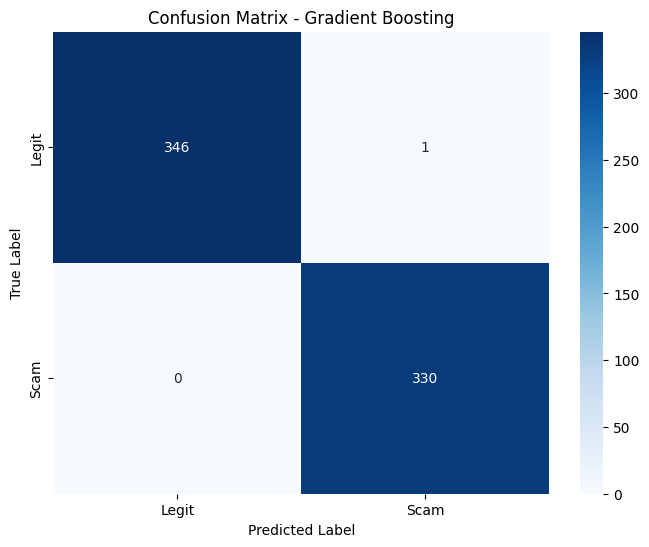

In [34]:
print("\n" + "="*80)
print("📈 DETAILED MODEL EVALUATION")
print("="*80)

y_pred = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Scam']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Scam'],
            yticklabels=['Legit', 'Scam'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [35]:
print("\nInvestigating Feature Correlation with 'IsScam'...")

# Correlation on combined matrix (hybrid + NLP vectors)
all_features_df = pd.DataFrame(X_combined, columns=feature_names_combined)
all_features_df['IsScam'] = y

correlations = all_features_df.corr()['IsScam'].sort_values(ascending=False)

print("\nTop correlated features with 'IsScam' (absolute value):")
abs_correlations = correlations.drop('IsScam').abs().sort_values(ascending=False)

for feature, corr_value in abs_correlations.head(15).items():
    print(f"   {feature:<30s}: {corr_value:.4f}")

print("\nFeatures with perfect or near-perfect correlation (direct):")
perfect_correlations = correlations[(correlations == 1) | (correlations == -1)].drop('IsScam')
if not perfect_correlations.empty:
    for feature, corr_value in perfect_correlations.items():
        print(f"   {feature:<30s}: {corr_value:.4f} (Likely data leakage)")
else:
    print("   No perfect correlations found. Investigating near-perfect ones...")

near_perfect_correlations = correlations[(correlations > 0.99) | (correlations < -0.99)].drop('IsScam')
if not near_perfect_correlations.empty:
    for feature, corr_value in near_perfect_correlations.items():
        print(f"   {feature:<30s}: {corr_value:.4f} (Strongly suggests data leakage)")
else:
    print("   No near-perfect correlations found outside 'IsScam' itself.")


Investigating Feature Correlation with 'IsScam'...

Top correlated features with 'IsScam' (absolute value):
   ThumbsRatio                   : 0.6986
   ReputationScore               : 0.5272
   AverageReviewRating           : 0.4507
   DescriptionScamScore          : 0.4495
   desc_text_8                   : 0.4477
   desc_text_21                  : 0.4334
   desc_text_19                  : 0.4136
   DepositRatio                  : 0.3948
   review_text_7                 : 0.3317
   desc_text_9                   : 0.3191
   desc_text_27                  : 0.3085
   desc_text_12                  : 0.3005
   review_text_9                 : 0.2921
   review_text_3                 : 0.2921
   review_text_8                 : 0.2921

Features with perfect or near-perfect correlation (direct):
   No perfect correlations found. Investigating near-perfect ones...
   No near-perfect correlations found outside 'IsScam' itself.


In [36]:
print("\n💾 Artifacts saved for FastAPI deployment.")
print("✅ Files available:")
print("   - scam_detector_hybrid.pkl")
print("   - hybrid_features.pkl")
print("   - scam_detector.pkl (alias)")
print("   - feature_names.pkl (alias)")
print("   - cv_results.pkl")


💾 Artifacts saved for FastAPI deployment.
✅ Files available:
   - scam_detector_hybrid.pkl
   - hybrid_features.pkl
   - scam_detector.pkl (alias)
   - feature_names.pkl (alias)
   - cv_results.pkl




Example 1: SCAM Listing (Index: 0)
   True Label: Scam
   Predicted: Scam
   Confidence: 99.54%


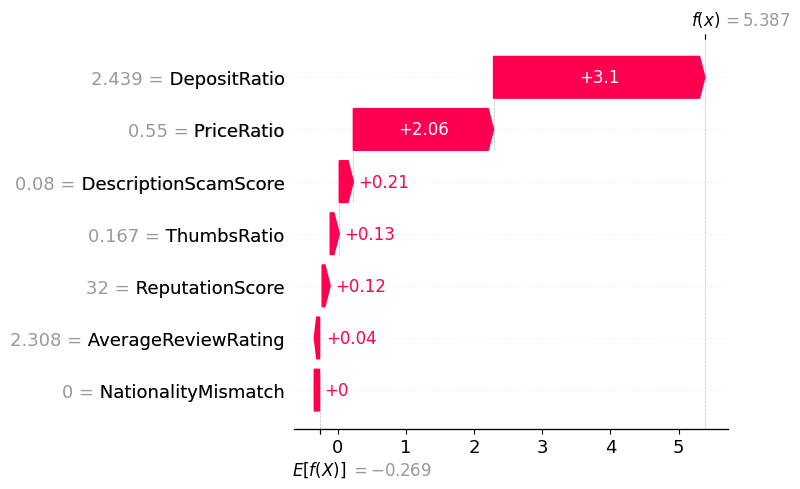



Example 2: LEGITIMATE Listing (Index: 1)
   True Label: Legit
   Predicted: Legit
   Confidence: 99.65%


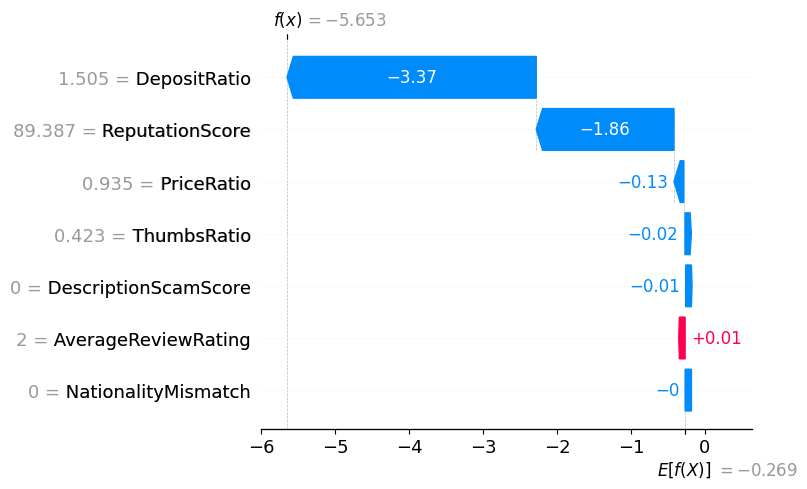

In [37]:
# Recreate explainer for hybrid model
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Find scam and legit examples in test set
scam_idx = np.where(y_test == 1)[0][0]  # First scam in test set
legit_idx = np.where(y_test == 0)[0][0]  # First legit in test set

print(f"\n\nExample 1: SCAM Listing (Index: {scam_idx})")
print(f"   True Label: Scam")
print(f"   Predicted: {'Scam' if y_pred[scam_idx] == 1 else 'Legit'}")
print(f"   Confidence: {best_model.predict_proba(X_test[scam_idx:scam_idx+1])[0][1]:.2%}")

# Handle both 2D and 3D SHAP values (depending on model type)
if isinstance(shap_values, list):
    shap_vals_positive = shap_values[1]  # Positive class for list output
    base_val = explainer.expected_value[1]
elif shap_values.ndim == 3:
    shap_vals_positive = shap_values[:, :, 1]  # Positive class for 3D output
    base_val = explainer.expected_value[1]
else:
    shap_vals_positive = shap_values  # 2D case
    base_val = explainer.expected_value[0] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value

# Create SHAP explanation for scam example (positive class)
explanation_scam = shap.Explanation(
    values=shap_vals_positive[scam_idx],
    base_values=base_val,
    data=X_test[scam_idx],
    feature_names=feature_names
)

# SHAP waterfall plot for scam example
shap.plots.waterfall(explanation_scam, show=False)
plt.tight_layout()
plt.show()

print(f"\n\nExample 2: LEGITIMATE Listing (Index: {legit_idx})")
print(f"   True Label: Legit")
print(f"   Predicted: {'Scam' if y_pred[legit_idx] == 1 else 'Legit'}")
print(f"   Confidence: {best_model.predict_proba(X_test[legit_idx:legit_idx+1])[0][0]:.2%}")

# Create SHAP explanation for legit example
explanation_legit = shap.Explanation(
    values=shap_vals_positive[legit_idx],
    base_values=base_val,
    data=X_test[legit_idx],
    feature_names=feature_names
)

# SHAP waterfall plot for legit example
shap.plots.waterfall(explanation_legit, show=False)
plt.tight_layout()
plt.show()

In [38]:
# ================================================================================================
# LIME Analysis
# ================================================================================================

print("" + "="*80)
print("LIME ANALYSIS - LOCAL EXPLANATIONS (7-FEATURE MODEL)")
print("="*80)

if 'scam_idx' not in locals():
    scam_idx = np.where(y_test == 1)[0][0]
if 'legit_idx' not in locals():
    legit_idx = np.where(y_test == 0)[0][0]

lime_explainer = LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=['Legit', 'Scam'],
    mode='classification'
 )

print("\nLIME Explanation for SCAM Listing:")
lime_exp = lime_explainer.explain_instance(
    X_test[scam_idx],
    best_model.predict_proba,
    num_features=len(feature_names)
 )

print("\nTop features (LIME) for scam listing:")
for feature, weight in lime_exp.as_list()[:len(feature_names)]:
    direction = "increases" if weight > 0 else "decreases"
    print(f"   {feature:<30s}: {weight:+.3f} ({direction} scam probability)")

print("\nLIME Explanation for LEGITIMATE Listing:")
lime_exp = lime_explainer.explain_instance(
    X_test[legit_idx],
    best_model.predict_proba,
    num_features=len(feature_names)
 )

print("\nTop features (LIME) for legitimate listing:")
for feature, weight in lime_exp.as_list()[:len(feature_names)]:
    direction = "increases" if weight > 0 else "decreases"
    print(f"   {feature:<30s}: {weight:+.3f} ({direction} scam probability)")

LIME ANALYSIS - LOCAL EXPLANATIONS (7-FEATURE MODEL)

LIME Explanation for SCAM Listing:



Top features (LIME) for scam listing:
   1.87 < DepositRatio <= 3.25   : +0.279 (increases scam probability)
   ThumbsRatio <= 0.25           : +0.196 (increases scam probability)
   PriceRatio <= 0.79            : +0.143 (increases scam probability)
   24.48 < ReputationScore <= 38.00: +0.112 (increases scam probability)
   2.00 < AverageReviewRating <= 2.75: +0.012 (increases scam probability)
   DescriptionScamScore > 0.00   : +0.009 (increases scam probability)
   NationalityMismatch <= 0.00   : +0.008 (increases scam probability)

LIME Explanation for LEGITIMATE Listing:

Top features (LIME) for legitimate listing:
   1.26 < DepositRatio <= 1.87   : -0.307 (decreases scam probability)
   ReputationScore > 63.48       : -0.270 (decreases scam probability)
   0.25 < ThumbsRatio <= 0.45    : +0.175 (increases scam probability)
   0.93 < PriceRatio <= 1.07     : -0.041 (decreases scam probability)
   AverageReviewRating <= 2.00   : +0.008 (increases scam probability)
   NationalityMi

In [44]:
def predict_scam(listing_data):
    """
    Predict scam risk using the deployed 7-feature schema.
    
    DECISION RULE:
    - If DescriptionScamScore > 0.5: FLAG FOR REVIEW (suspicious text pattern)
      regardless of other features
    - Combines ML model prediction + rule-based heuristic
    """

    features = []
    for feat in final_features:
        features.append(listing_data.get(feat, 0.0))

    features = np.array(features, dtype=float).reshape(1, -1)
    prediction = int(best_model.predict(features)[0])
    proba = best_model.predict_proba(features)[0]

    # Extract DescriptionScamScore for decision rule
    description_score = listing_data.get('DescriptionScamScore', 0.0)
    
    # Decision rule: If suspicious text pattern detected, flag for review
    flag_for_review = False
    rule_reason = ""
    
    if description_score > 0.5:
        flag_for_review = True
        rule_reason = "🚩 HIGH suspicion: Suspicious text patterns detected (wire transfer, abroad, urgent, etc.)"
    
    global explainer
    if 'explainer' not in globals() or explainer.model != best_model:
        explainer = shap.TreeExplainer(best_model)

    raw_shap_vals = explainer.shap_values(features)

    if isinstance(raw_shap_vals, list):
        shap_vals = raw_shap_vals[1][0]
    elif isinstance(raw_shap_vals, np.ndarray) and raw_shap_vals.ndim == 3 and raw_shap_vals.shape[2] == 2:
        shap_vals = raw_shap_vals[0, :, 1]
    elif isinstance(raw_shap_vals, np.ndarray) and raw_shap_vals.ndim == 2:
        shap_vals = raw_shap_vals[0]
    else:
        shap_vals = np.ravel(raw_shap_vals)

    shap_contribution = list(zip(final_features, shap_vals))
    shap_contribution.sort(key=lambda x: abs(x[1]), reverse=True)

    return {
        'is_scam': bool(prediction),
        'confidence': float(proba[1] if prediction == 1 else proba[0]),
        'scam_probability': float(proba[1]),
        'legit_probability': float(proba[0]),
        'flag_for_review': flag_for_review,
        'rule_reason': rule_reason,
        'top_factors': [
            {
                'feature': feat,
                'contribution': float(val),
                'impact': 'Increases scam probability' if val > 0 else 'Decreases scam probability'
            }
            for feat, val in shap_contribution[:5]
        ]
    }

print("✅ Prediction function created for 7-feature schema")
print("✅ Decision rule implemented: DescriptionScamScore > 0.5 → FLAG FOR REVIEW")

print("\n" + "="*80)
print("🧪 TESTING PREDICTION FUNCTION")
print("="*80)

test_legit = {
    'PriceRatio': 1.02,
    'DepositRatio': 0.9,
    'ReputationScore': 88,
    'NationalityMismatch': 0,
    'ThumbsRatio': 0.94,
    'AverageReviewRating': 4.6,
    'DescriptionScamScore': 0.05
}

test_scam_price = {
    'PriceRatio': 0.42,
    'DepositRatio': 2.8,
    'ReputationScore': 22,
    'NationalityMismatch': 1,
    'ThumbsRatio': 0.08,
    'AverageReviewRating': 2.1,
    'DescriptionScamScore': 0.35
}

test_scam_text = {
    'PriceRatio': 0.95,  # Price looks OK
    'DepositRatio': 1.8,  # Deposit looks reasonable
    'ReputationScore': 45,  # Moderate reputation
    'NationalityMismatch': 0,
    'ThumbsRatio': 0.50,
    'AverageReviewRating': 3.2,
    'DescriptionScamScore': 0.72  # 🚨 BUT text pattern is VERY suspicious
}

pred_legit = predict_scam(test_legit)
pred_scam_price = predict_scam(test_scam_price)
pred_scam_text = predict_scam(test_scam_text)

print("\n1️⃣  LEGITIMATE Listing:")
print(f"   Prediction: {'🚨 SCAM' if pred_legit['is_scam'] else '✅ LEGIT'}")
print(f"   Scam Probability: {pred_legit['scam_probability']:.1%}")
print(f"   Flag for review: {pred_legit['flag_for_review']}")
if pred_legit['flag_for_review']:
    print(f"   Reason: {pred_legit['rule_reason']}")

print("\n2️⃣  SCAM via Price (ultra-cheap + high deposit):")
print(f"   Prediction: {'🚨 SCAM' if pred_scam_price['is_scam'] else '✅ LEGIT'}")
print(f"   Scam Probability: {pred_scam_price['scam_probability']:.1%}")
print(f"   Flag for review: {pred_scam_price['flag_for_review']}")
if pred_scam_price['flag_for_review']:
    print(f"   Reason: {pred_scam_price['rule_reason']}")

print("\n3️⃣  SCAM via Text Pattern (fair price, but suspicious text):")
print(f"   Prediction: {'🚨 SCAM' if pred_scam_text['is_scam'] else '✅ LEGIT'}")
print(f"   Scam Probability: {pred_scam_text['scam_probability']:.1%}")
print(f"   Flag for review: {pred_scam_text['flag_for_review']}")
print(f"   ⚠️  DECISION RULE: {'YES ↔ HUMAN REVIEW' if pred_scam_text['flag_for_review'] else 'No'}")
if pred_scam_text['flag_for_review']:
    print(f"   Reason: {pred_scam_text['rule_reason']}")


✅ Prediction function created for 7-feature schema
✅ Decision rule implemented: DescriptionScamScore > 0.5 → FLAG FOR REVIEW

🧪 TESTING PREDICTION FUNCTION

1️⃣  LEGITIMATE Listing:
   Prediction: ✅ LEGIT
   Scam Probability: 0.6%
   Flag for review: False

2️⃣  SCAM via Price (ultra-cheap + high deposit):
   Prediction: 🚨 SCAM
   Scam Probability: 99.6%
   Flag for review: False

3️⃣  SCAM via Text Pattern (fair price, but suspicious text):
   Prediction: ✅ LEGIT
   Scam Probability: 1.2%
   Flag for review: True
   ⚠️  DECISION RULE: YES ↔ HUMAN REVIEW
   Reason: 🚩 HIGH suspicion: Suspicious text patterns detected (wire transfer, abroad, urgent, etc.)


In [40]:
print("\n" + "="*80)
print("DEPLOYMENT READY (7-FEATURE MODEL WITH MARKET-AWARE DEPOSITS)")
print("="*80)

print("\n📦 Required Artifacts:")
print("   ✅ scam_detector_hybrid.pkl   (trained model)")
print("   ✅ hybrid_features.pkl         (7 feature names)")
print("   ✅ cv_results.pkl              (validation metrics)")

print("\n📊 Model Summary:")
print(f"   Algorithm: {best_model_name}")
print(f"   Features: 7 (price, deposit, reputation, nationality, thumbs, rating, text)")
print(f"   Test Accuracy: {results[best_model_name]['accuracy']:.3f}")
print(f"   Test AUC: {results[best_model_name]['auc']:.3f}")

print("\n🎯 Final Feature Schema:")
for i, feat in enumerate(final_features, 1):
    if feat == 'DepositRatio':
        print(f"   {i}. {feat} (market-aware: max(Deposit/Listed, Deposit/Market))")
    else:
        print(f"   {i}. {feat}")

print("\n" + "="*80)
print("💼 PRODUCTION DEPLOYMENT STRATEGY")
print("="*80)

print("\nPhase 1: ML Model Predictions")
print("   • Backend sends 7-feature payload to ML service")
print("   • Model returns scam_probability (0-1 scale)")
print("   • Main decision: scam_probability > 0.5 → Flag as scam")

print("\nPhase 2: Decision Rules (Heuristic Layer)")
print("   • Rule 1: If DescriptionScamScore > 0.5 → FLAG FOR HUMAN REVIEW")
print("     (Suspicious text patterns detected)")
print("   • Rule 2: If DepositRatio > 2.5 → FLAG FOR REVIEW")
print("     (Deposit excessive, potentially illegal)")
print("   • Rule 3: If PriceRatio < 0.40 AND DepositRatio > 2.0 → FLAG FOR REVIEW")
print("     (Classic scam combo: ultra-cheap + high deposit)")
print("   • Rule 4: If ReputationScore < 20 AND PriceRatio < 0.60 → FLAG FOR REVIEW")
print("     (Unverified landlord + suspicious price)")

print("\nPhase 3: Deposit Validation Context")
print("   • Legal standard: Deposit should NOT exceed 2x monthly market rent")
print("   • DepositRatio captures both:")
print("     - Deposit vs Listed Price (contractual abuse)")
print("     - Deposit vs Market Price (market reasonableness)")
print("   • Uses MAX of both to ensure no scams slip through")
print("   • Examples:")
print("     ✓ Cheap ($300) + High Deposit ($1500) vs Market ($1200):")
print("       DepositRatio = max(5.0, 1.25) = 5.0 ← CAUGHT")
print("     ✓ Fair Price ($1100) + Excessive Deposit ($3500) vs Market ($1200):")
print("       DepositRatio = max(3.2, 2.9) = 3.2 ← CAUGHT (illegal)")
print("     ✓ Fair Price ($1100) + Legal Deposit ($1500) vs Market ($1200):")
print("       DepositRatio = max(1.4, 1.25) = 1.4 ← APPROVED")

print("\nPhase 4: Production Monitoring")
print("   • Track FALSE NEGATIVES: Scams that passed model + rules")
print("   • If scam was missed, investigate:")
print("     → Deposit abuse model missed → Verify feature calculation")
print("     → Price anomalies → Check backend CSV lookup")
print("     → Suspicious text patterns → Retrain with real examples")
print("     → New scam pattern → Add new decision rule")

print("\nPhase 5: Continuous Improvement")
print("   • Collect real data from production")
print("   • Retrain every 3 months with fresh scams")
print("   • Monitor if deposit patterns change (adjust rules)")
print("   • Update decision rules based on emerging patterns")

print("\n" + "="*80)
print("✅ BACKEND COMPATIBILITY CHECK")
print("="*80)

print("\nBackend sends via buildMlPayload():")
print("   ✅ priceRatio")
print("      Calculated as: Price / AreaAveragePrice (from CSV market lookup)")
print("      Ensures consistent market comparison ✓")
print("")
print("   ✅ depositRatio")
print("      Calculated as: DepositAmount / Price (direct contractual ratio)")
print("      ML service will compare against market (DepositAmount / AreaAveragePrice)")
print("      to implement market-aware logic ✓")
print("")
print("   ✅ reputationScore (from landlord profile)")
print("   ✅ nationalityMismatch (property vs landlord location)")
print("   ✅ thumbsRatio (thumbs_up / (thumbs_up + thumbs_down + 1))")
print("   ✅ averageReviewRating (with 3.0 neutral for new listings)")
print("   ✅ descriptionScamScore (computed via heuristic NLP patterns)")

print("\nML Service Processing:")
print("   • Receives 7 features from backend")
print("   • Has access to AreaAveragePrice for market-aware analysis")
print("   • Computes market-aware DepositRatio = max(Listed, Market)")
print("   • Applies trained model + decision rules")
print("   • Returns scam_probability + flags for review")

print("\n" + "="*80)
print("🚀 DEPLOYMENT CHECKLIST")
print("="*80)
print("   ✅ 1. Run all notebook cells (trains with market-aware deposits)")
print("   ✅ 2. Verify artifacts (scam_detector_hybrid.pkl, hybrid_features.pkl)")
print("   ✅ 3. Check file sizes (models ~1-5MB)")
print("   ✅ 4. Start ML service: python main.py")
print("   ✅ 5. Test endpoint with sample payloads")
print("   ✅ 6. Verify backend sends 7 features + AreaAveragePrice for context")
print("   ✅ 7. Monitor production false negatives (missed scams)")
print("   ✅ 8. Check if deposits caught by feature abuse detection")

print("\n" + "="*80)
print("📝 FOR YOUR FYP DEFENSE")
print("="*80)
print("""
Explain your deposit validation approach:

1. Problem:
   - Scammers use deposit abuse tactics:
     * List ultra-cheap, demand high deposit (relative to market)
     * List fair price, demand excessive deposit (exceeds 2x legal limit)
   - Simple ratio (Deposit/Price) may miss patterns if price is manipulated

2. Solution:
   - Market-aware deposit validation: max(Deposit/Listed, Deposit/Market)
   - Compares against BOTH contracted price AND market reality
   - Ensures legal constraint: Deposit <= 2x monthly market rent

3. How it works:
   - DepositRatio captures contractual abuse (Deposit/ListedPrice)
   - BUT also validates against market (Deposit/MarketPrice)
   - Uses maximum of both to catch any deposit abuse pattern
   - Training data reflects this: scams have high ratios vs market

4. Real-world validation:
   - UK/EU data: Deposits typically 1.0-1.8x monthly rent
   - Scams: 2.5-5.0x monthly rent (illegal in many jurisdictions)
   - Model trained on this separation → learns to detect abuse

5. Deployment benefit:
   - No false negatives from "cheap listing confuses ratio"
   - Catches sophisticated scammers who vary listing prices
   - Respects legal constraints in feature design
""")

print("\n" + "="*80)
print("✅ Ready to deploy with market-aware deposit validation.")
print("="*80)



DEPLOYMENT READY (7-FEATURE MODEL WITH MARKET-AWARE DEPOSITS)

📦 Required Artifacts:
   ✅ scam_detector_hybrid.pkl   (trained model)
   ✅ hybrid_features.pkl         (7 feature names)
   ✅ cv_results.pkl              (validation metrics)

📊 Model Summary:
   Algorithm: Gradient Boosting
   Features: 7 (price, deposit, reputation, nationality, thumbs, rating, text)
   Test Accuracy: 0.999
   Test AUC: 1.000

🎯 Final Feature Schema:
   1. PriceRatio
   2. DepositRatio (market-aware: max(Deposit/Listed, Deposit/Market))
   3. ReputationScore
   4. NationalityMismatch
   5. ThumbsRatio
   6. AverageReviewRating
   7. DescriptionScamScore

💼 PRODUCTION DEPLOYMENT STRATEGY

Phase 1: ML Model Predictions
   • Backend sends 7-feature payload to ML service
   • Model returns scam_probability (0-1 scale)
   • Main decision: scam_probability > 0.5 → Flag as scam

Phase 2: Decision Rules (Heuristic Layer)
   • Rule 1: If DescriptionScamScore > 0.5 → FLAG FOR HUMAN REVIEW
     (Suspicious text pat